In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# GENERAL PLOT OPTIONS
# GENERAL PLOT OPTIONS
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['mathtext.rm'] = 'Bitstream Vera Sans'
matplotlib.rcParams['mathtext.it'] = 'Bitstream Vera Sans:italic'
matplotlib.rcParams['mathtext.bf'] = 'Bitstream Vera Sans:bold'
matplotlib.rcParams['xtick.bottom'] = True
matplotlib.rcParams['xtick.top'] = False
matplotlib.rcParams['ytick.right'] = False
matplotlib.rcParams['axes.edgecolor'] = 'black'
matplotlib.rcParams['axes.linewidth'] = '1.0'
matplotlib.rcParams['axes.labelsize'] = 'medium'
matplotlib.rcParams['axes.grid'] = True
matplotlib.rcParams['grid.linewidth'] = '0.0'
matplotlib.rcParams['grid.alpha'] = '0.18'
matplotlib.rcParams['grid.color'] = 'lightgray'
matplotlib.rcParams['legend.labelspacing'] = 0.77
matplotlib.rcParams['savefig.bbox'] = 'tight'
matplotlib.rcParams['savefig.format'] = 'pdf'

from scipy.interpolate import interp1d
from scipy.integrate import quad

AttributeError: module 'matplotlib.pyplot' has no attribute 'savepdf'

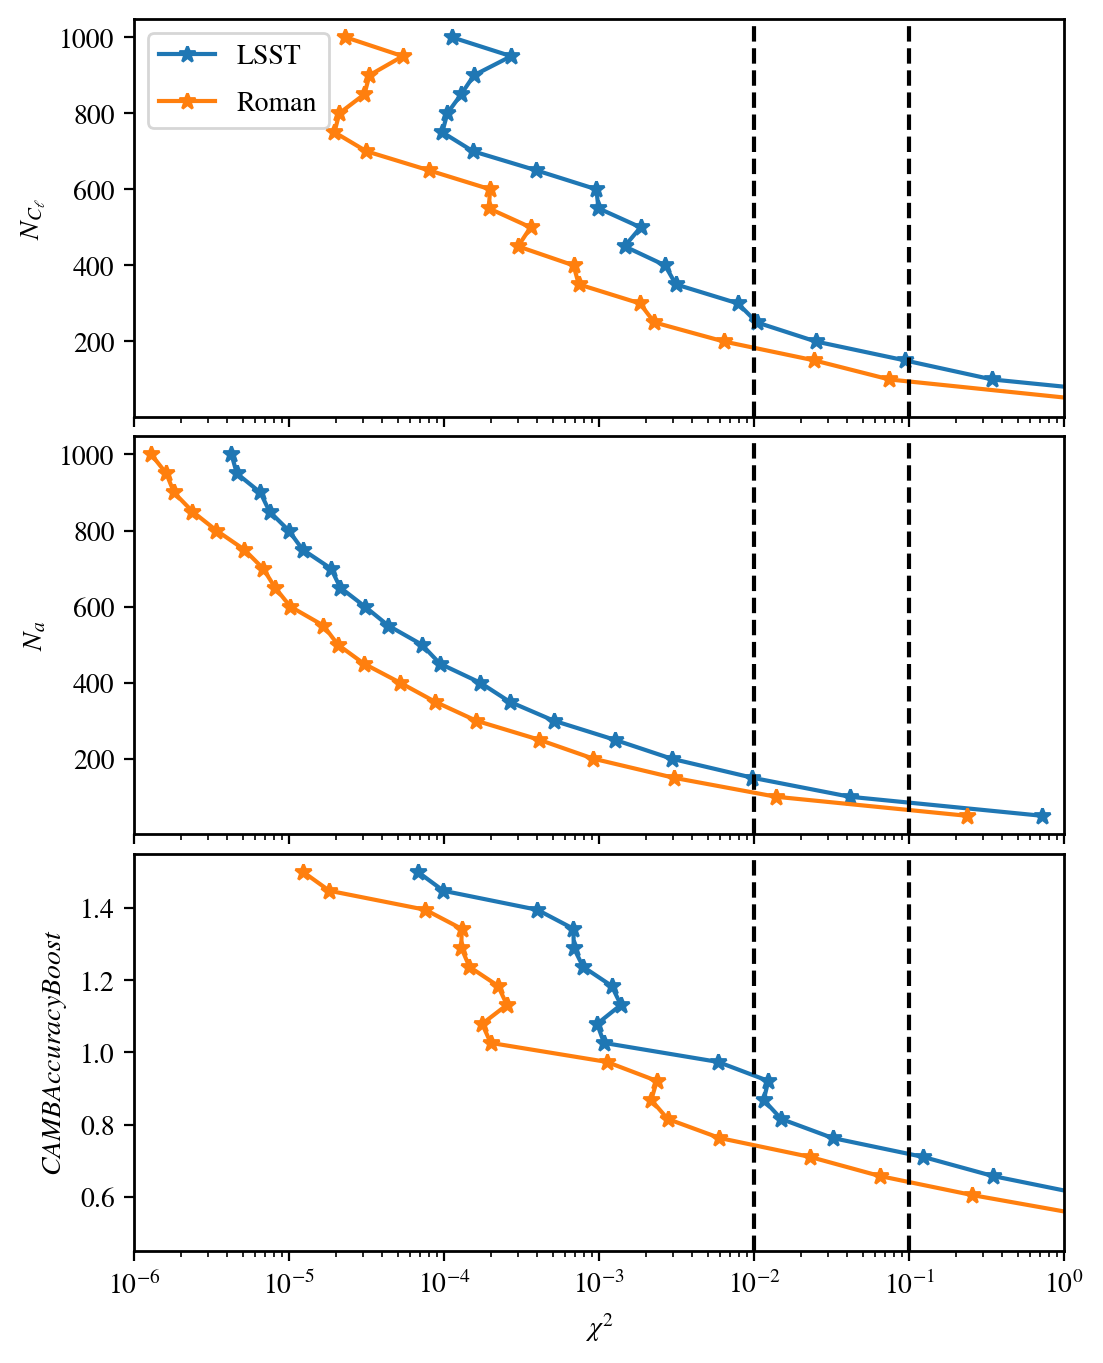

In [38]:
chi2s_lsst = np.loadtxt('../lsst_real/chi2s_NCl.txt')
chi2s_roman = np.loadtxt('../roman_real/chi2s_NCl.txt')

chi2s_lsst = np.loadtxt('../lsst_real/chi2s_Na.txt')
chi2s_roman = np.loadtxt('../roman_real/chi2s_Na.txt')

chi2s_lsst = np.loadtxt('../lsst_real/chi2s_CAMBAB.txt')
chi2s_roman = np.loadtxt('../roman_real/chi2s_CAMBAB.txt')

fig,axs = plt.subplots(3,1,figsize=(6,8))
plt.subplots_adjust(hspace=0.05)
xmin = 1e-6
xmax = 1e0

#subplot1
chi2s_lsst = np.loadtxt('../lsst_real/chi2s_NCl.txt')
chi2s_roman = np.loadtxt('../roman_real/chi2s_NCl.txt')

axs[0].plot(chi2s_lsst[:,1], chi2s_lsst[:,0],  '*-', label='LSST')
axs[0].plot(chi2s_roman[:,1], chi2s_roman[:,0], '*-', label='Roman')
axs[0].set_xlim(xmin, xmax)

axs[0].axvline(ymin=0, ymax=1, x=1e-1, linestyle='--', color='k')
axs[0].axvline(ymin=0, ymax=1, x=1e-2, linestyle='--', color='k')

axs[0].tick_params(axis='x', labelbottom=False)
axs[0].set_xscale('log')
#axs[0].set_yscale('log')
axs[0].set_ylabel(r'$N_{C_\ell}$')
axs[0].legend(['LSST','Roman'])

#subplot2
chi2s_lsst = np.loadtxt('../lsst_real/chi2s_Na.txt')
chi2s_roman = np.loadtxt('../roman_real/chi2s_Na.txt')

axs[1].plot(chi2s_lsst[:,1], chi2s_lsst[:,0],  '*-', label='LSST')
axs[1].plot(chi2s_roman[:,1], chi2s_roman[:,0], '*-', label='Roman')
axs[1].set_xlim(xmin, xmax)

axs[1].axvline(ymin=0, ymax=1, x=1e-1, linestyle='--', color='k')
axs[1].axvline(ymin=0, ymax=1, x=1e-2, linestyle='--', color='k')

axs[1].tick_params(axis='x', labelbottom=False)
axs[1].set_xscale('log')
#axs[1].set_yscale('log')
axs[1].set_ylabel(r'$N_a$')

#subplot3
chi2s_lsst = np.loadtxt('../lsst_real/chi2s_CAMBAB.txt')
chi2s_roman = np.loadtxt('../roman_real/chi2s_CAMBAB.txt')

axs[2].plot(chi2s_lsst[:,1], chi2s_lsst[:,0],  '*-', label='LSST')
axs[2].plot(chi2s_roman[:,1], chi2s_roman[:,0], '*-', label='Roman')
axs[2].set_xlim(xmin, xmax)

axs[2].axvline(ymin=0, ymax=1, x=1e-1, linestyle='--', color='k')
axs[2].axvline(ymin=0, ymax=1, x=1e-2, linestyle='--', color='k')

#axs[2].tick_params(axis='x', labelbottom=False)
axs[2].set_xscale('log')
axs[2].set_xlabel(r'$\chi^2$')
axs[2].set_ylabel(r'$CAMB AccuracyBoost$')

plt.savefig('accuracy_settings.png')


LSST: chi2 = 1e-2, the corresponding NCl = 148.82656870308426
LSST: chi2 = 1e-3, the corresponding NCl = 257.9035993922349
Roman: chi2 = 1e-2, the corresponding NCl = 98.8089046114485
Roman: chi2 = 1e-3, the corresponding NCl = 189.92647968370355


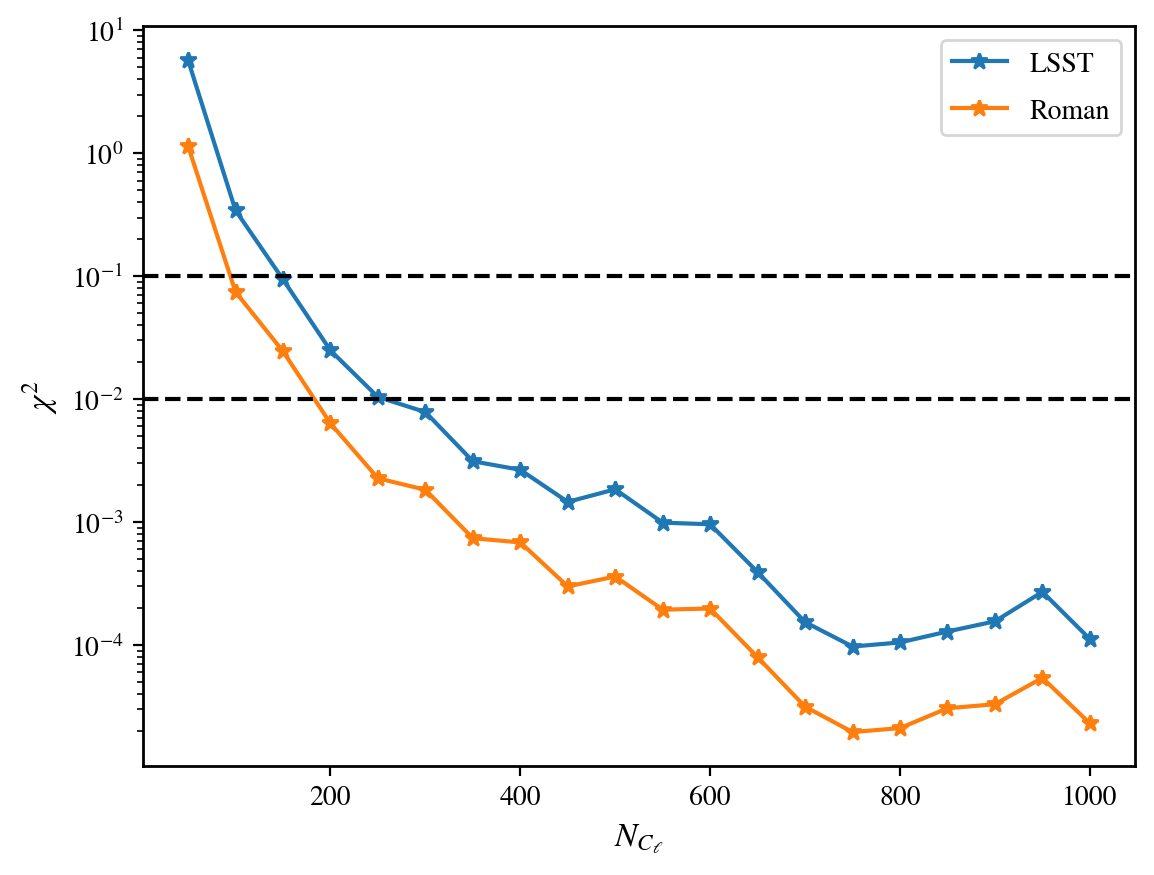

In [20]:
chi2s_lsst = np.loadtxt('../lsst_real/chi2s_NCl.txt')
chi2s_roman = np.loadtxt('../roman_real/chi2s_NCl.txt')
xmin = min(chi2s_lsst[:,0])
xmax = max(chi2s_lsst[:,0])

plt.plot(chi2s_lsst[:,0], chi2s_lsst[:,1], '*-', label='LSST')
fchi2 = interp1d(chi2s_lsst[:,1], chi2s_lsst[:,0])
print(f'LSST: chi2 = 1e-2, the corresponding NCl = {fchi2(1e-1)}')
print(f'LSST: chi2 = 1e-3, the corresponding NCl = {fchi2(1e-2)}')
plt.plot(chi2s_roman[:,0], chi2s_roman[:,1], '*-', label='Roman')
fchi2 = interp1d(chi2s_roman[:,1], chi2s_roman[:,0])
print(f'Roman: chi2 = 1e-2, the corresponding NCl = {fchi2(1e-1)}')
print(f'Roman: chi2 = 1e-3, the corresponding NCl = {fchi2(1e-2)}')

plt.axhline(xmin=0, xmax=1, y=1e-1, linestyle='--', color='k')
plt.axhline(xmin=0, xmax=1, y=1e-2, linestyle='--', color='k')

plt.yscale('log')
plt.xlabel(r'$N_{C_\ell}$')
plt.ylabel(r'$\chi^2$')
plt.legend()

LSST: chi2 = 1e-2, the corresponding Na = 95.65069384952085
LSST: chi2 = 1e-3, the corresponding Na = 149.57670066194686
Romam: chi2 = 1e-2, the corresponding Na = 80.48957326259708
Romam: chi2 = 1e-3, the corresponding Na = 117.64696173805552


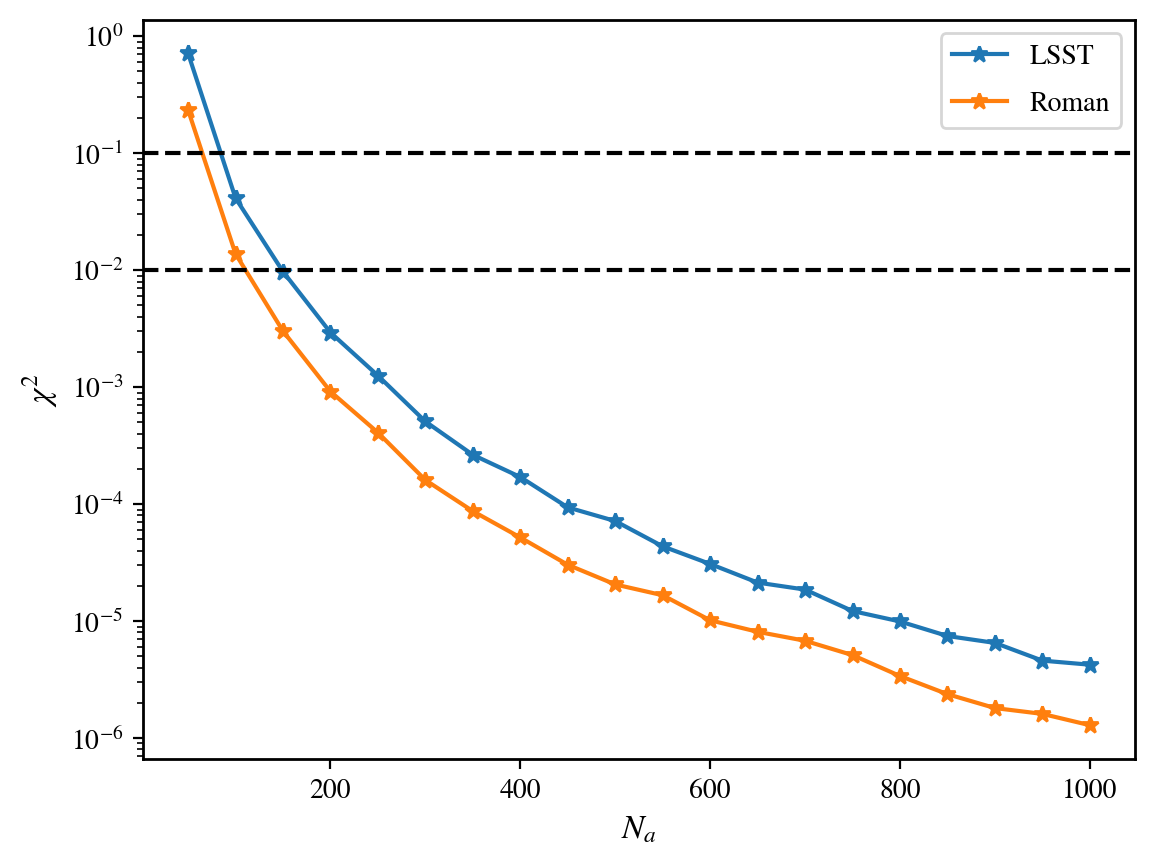

In [21]:
chi2s_lsst = np.loadtxt('../lsst_real/chi2s_Na.txt')
chi2s_roman = np.loadtxt('../roman_real/chi2s_Na.txt')
xmin = min(chi2s_lsst[:,0])
xmax = max(chi2s_lsst[:,0])

plt.plot(chi2s_lsst[:,0], chi2s_lsst[:,1], '*-', label='LSST')
fchi2 = interp1d(chi2s_lsst[:,1], chi2s_lsst[:,0])
print(f'LSST: chi2 = 1e-2, the corresponding Na = {fchi2(1e-1)}')
print(f'LSST: chi2 = 1e-3, the corresponding Na = {fchi2(1e-2)}')
plt.plot(chi2s_roman[:,0], chi2s_roman[:,1], '*-', label='Roman')
fchi2 = interp1d(chi2s_roman[:,1], chi2s_roman[:,0])
print(f'Romam: chi2 = 1e-2, the corresponding Na = {fchi2(1e-1)}')
print(f'Romam: chi2 = 1e-3, the corresponding Na = {fchi2(1e-2)}')
plt.axhline(xmin=0, xmax=1, y=1e-1, linestyle='--', color='k')
plt.axhline(xmin=0, xmax=1, y=1e-2, linestyle='--', color='k')

plt.yscale('log')
plt.xlabel(r'$N_a$')
plt.ylabel(r'$\chi^2$')
plt.legend()

LSST: chi2 = 1e-2, the corresponding CAMB AB = 0.7241022774436334
LSST: chi2 = 1e-3, the corresponding CAMB AB = 0.896606156085645
Romam: chi2 = 1e-2, the corresponding CAMB AB = 0.7241022774436334
Romam: chi2 = 1e-3, the corresponding CAMB AB = 0.896606156085645


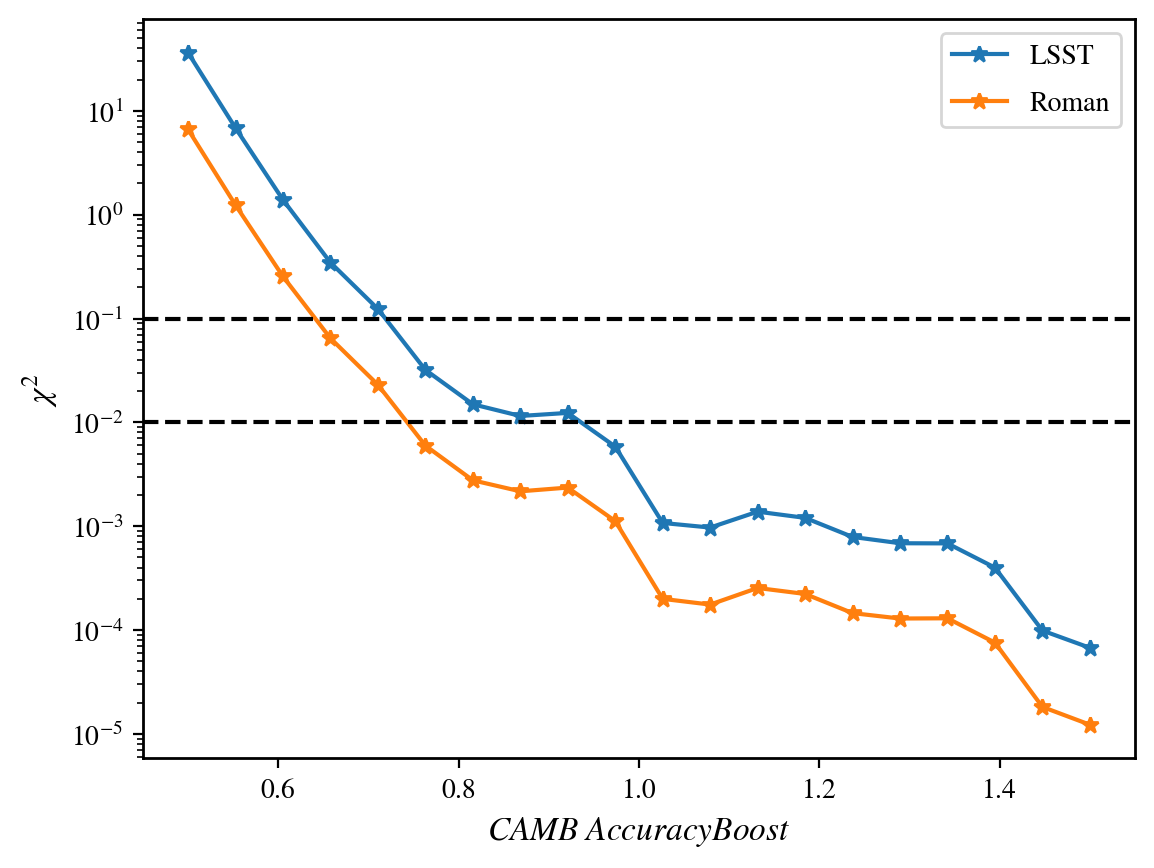

In [22]:
chi2s_lsst = np.loadtxt('../lsst_real/chi2s_CAMBAB.txt')
chi2s_roman = np.loadtxt('../roman_real/chi2s_CAMBAB.txt')
xmin = min(chi2s_lsst[:,0])
xmax = max(chi2s_lsst[:,0])

plt.plot(chi2s_lsst[:,0], chi2s_lsst[:,1], '*-', label='LSST')
fchi2 = interp1d(chi2s_lsst[:,1], chi2s_lsst[:,0])
print(f'LSST: chi2 = 1e-2, the corresponding CAMB AB = {fchi2(1e-1)}')
print(f'LSST: chi2 = 1e-3, the corresponding CAMB AB = {fchi2(1e-2)}')
plt.plot(chi2s_roman[:,0], chi2s_roman[:,1], '*-', label='Roman')
fchi2 = interp1d(chi2s_lsst[:,1], chi2s_lsst[:,0])
print(f'Romam: chi2 = 1e-2, the corresponding CAMB AB = {fchi2(1e-1)}')
print(f'Romam: chi2 = 1e-3, the corresponding CAMB AB = {fchi2(1e-2)}')
plt.axhline(xmin=0, xmax=1, y=1e-1, linestyle='--', color='k')
plt.axhline(xmin=0, xmax=1, y=1e-2, linestyle='--', color='k')

plt.yscale('log')
plt.xlabel(r'$CAMB\ AccuracyBoost$')
plt.ylabel(r'$\chi^2$')
plt.legend()

### now compare real datavectors

In [13]:
### Roman
import scipy
nlens = 10
nsrcs = 8
ntheta = 20
ndv = int(nsrcs*(nsrcs+1) + nlens*nsrcs + nlens)*ntheta

cov_raw = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real/data/cov_roman')
cov = np.zeros((ndv,ndv))
for idx in range(len(cov_raw)):
    ii = int(cov_raw[idx, 0])
    jj = int(cov_raw[idx, 1])
    element = cov_raw[idx, 8] + cov_raw[idx, 9]
    cov[ii,jj] = element
    cov[jj,ii] = element
    
mask = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real/data/roman_Y3.mask')[:,1].astype(bool)
invcov = scipy.linalg.inv(cov[mask,:][:,mask])

dv_hi = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real/chains/roman_baseline_evaluate/roman_baseline.modelvector')[:,1]
dv_lo = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real/chains/roman_lowprecision_evaluate/roman_lowprecision.modelvector')[:,1]

delta = (dv_hi - dv_lo)[mask]
chi2_roman = delta@invcov@delta
print('Roman: chi2 of high and low precision', chi2_roman)

Roman: chi2 of high and low precision 0.007224230015844515


In [9]:
### roman
import scipy
nlens = 10
nsrcs = 8
ntheta = 20
ndv = int(nsrcs*(nsrcs+1) + nlens*nsrcs + nlens)*ntheta

cov_raw = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real/data/cov_roman')
cov = np.zeros((ndv,ndv))
for idx in range(len(cov_raw)):
    ii = int(cov_raw[idx, 0])
    jj = int(cov_raw[idx, 1])
    element = cov_raw[idx, 8] + cov_raw[idx, 9]
    cov[ii,jj] = element
    cov[jj,ii] = element
    
mask = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real/data/roman_Y3.mask')[:,1].astype(bool)
invcov = scipy.linalg.inv(cov[mask,:][:,mask])

dv_base = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real/chains/roman_baseline_evaluate/roman_baseline.modelvector')[:,1]
dv_lo = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real/chains/roman_lowprecision_evaluate/roman_lowprecision.modelvector')[:,1]

delta = (dv_base - dv_lo)[mask]
chi2_roman = delta@invcov@delta
print('Roman: chi2 between baseline and low-precision datavector', chi2_roman)

dv_limber = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real/chains/roman_limber_evaluate/roman_limber.modelvector')[:,1]
delta = (dv_base - dv_limber)[mask]
chi2_roman = delta@invcov@delta
print('Roman: chi2 between baseline and limber datavector', chi2_roman)

dv_noRSD = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real/chains/roman_noRSD_evaluate/roman_noRSD.modelvector')[:,1]
delta = (dv_base - dv_noRSD)[mask]
chi2_roman = delta@invcov@delta
print('Roman: chi2 between baseline and noRSD datavector', chi2_roman)

dv_limber_noRSD = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real/chains/roman_limber+noRSD_evaluate/roman_limber+noRSD.modelvector')[:,1]
delta = (dv_base - dv_limber_noRSD)[mask]
chi2_roman = delta@invcov@delta
print('Roman: chi2 between baseline and limber+noRSD datavector', chi2_roman)

dv_limber_noRSD_gg = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real/chains/roman_limber+noRSD_gg_evaluate/roman_limber+noRSD_gg.modelvector')[:,1]
delta = (dv_base - dv_limber_noRSD_gg)[mask]
chi2_roman = delta@invcov@delta
print('Roman: chi2 between baseline and limber+noRSD_gg datavector', chi2_roman)

dv_limber_noRSD_gs = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real/chains/roman_limber+noRSD_gs_evaluate/roman_limber+noRSD_gs.modelvector')[:,1]
delta = (dv_base - dv_limber_noRSD_gs)[mask]
chi2_roman = delta@invcov@delta
print('Roman: chi2 between baseline and limber+noRSD_gs datavector', chi2_roman)

dv_hmcode20 = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real/chains/roman_hmcode20_evaluate/roman_hmcode20.modelvector')[:,1]
delta = (dv_base - dv_hmcode20)[mask]
chi2_roman = delta@invcov@delta
print('Roman: chi2 between baseline and hmcode20 datavector', chi2_roman)

dv_takahashi = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/roman_real/chains/roman_takahashi_evaluate/roman_takahashi.modelvector')[:,1]
delta = (dv_base - dv_takahashi)[mask]
chi2_roman = delta@invcov@delta
print('Roman: chi2 between baseline and takahashi datavector', chi2_roman)

Roman: chi2 between baseline and low-precision datavector 0.0075248000710280705
Roman: chi2 between baseline and limber datavector 23.85427829416193
Roman: chi2 between baseline and noRSD datavector 0.03429939937524819
Roman: chi2 between baseline and limber+noRSD datavector 28.52743891079576
Roman: chi2 between baseline and limber+noRSD_gg datavector 28.6355921156359
Roman: chi2 between baseline and limber+noRSD_gs datavector 23.75695832760812
Roman: chi2 between baseline and hmcode20 datavector 6.751508305570008
Roman: chi2 between baseline and takahashi datavector 5.767639706925268


In [10]:
### lsst
import scipy
nlens = 10
nsrcs = 5
ntheta = 20
ndv = int(nsrcs*(nsrcs+1) + nlens*nsrcs + nlens)*ntheta

cov_raw = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/lsst_real/data/cov_lsst')
cov = np.zeros((ndv,ndv))
for idx in range(len(cov_raw)):
    ii = int(cov_raw[idx, 0])
    jj = int(cov_raw[idx, 1])
    element = cov_raw[idx, 8] + cov_raw[idx, 9]
    cov[ii,jj] = element
    cov[jj,ii] = element
    
mask = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/lsst_real/data/lsst_Y3.mask')[:,1].astype(bool)
invcov = scipy.linalg.inv(cov[mask,:][:,mask])

dv_base = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/lsst_real/chains/lsst_baseline_evaluate/lsst_baseline.modelvector')[:,1]
dv_lo = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/lsst_real/chains/lsst_lowprecision_evaluate/lsst_lowprecision.modelvector')[:,1]

delta = (dv_base - dv_lo)[mask]
chi2_lsst = delta@invcov@delta
print('LSST: chi2 between baseline and low-precision datavector', chi2_lsst)

dv_limber = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/lsst_real/chains/lsst_limber_evaluate/lsst_limber.modelvector')[:,1]
delta = (dv_base - dv_limber)[mask]
chi2_lsst = delta@invcov@delta
print('LSST: chi2 between baseline and limber datavector', chi2_lsst)

dv_noRSD = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/lsst_real/chains/lsst_noRSD_evaluate/lsst_noRSD.modelvector')[:,1]
delta = (dv_base - dv_noRSD)[mask]
chi2_lsst = delta@invcov@delta
print('LSST: chi2 between baseline and noRSD datavector', chi2_lsst)

dv_limber_noRSD = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/lsst_real/chains/lsst_limber+noRSD_evaluate/lsst_limber+noRSD.modelvector')[:,1]
delta = (dv_base - dv_limber_noRSD)[mask]
chi2_lsst = delta@invcov@delta
print('LSST: chi2 between baseline and limber+noRSD datavector', chi2_lsst)

dv_limber_noRSD_gg = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/lsst_real/chains/lsst_limber+noRSD_gg_evaluate/lsst_limber+noRSD_gg.modelvector')[:,1]
delta = (dv_base - dv_limber_noRSD_gg)[mask]
chi2_lsst = delta@invcov@delta
print('LSST: chi2 between baseline and limber+noRSD_gg datavector', chi2_lsst)

dv_limber_noRSD_gs = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/lsst_real/chains/lsst_limber+noRSD_gs_evaluate/lsst_limber+noRSD_gs.modelvector')[:,1]
delta = (dv_base - dv_limber_noRSD_gs)[mask]
chi2_lsst = delta@invcov@delta
print('LSST: chi2 between baseline and limber+noRSD_gs datavector', chi2_lsst)

dv_hmcode20 = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/lsst_real/chains/lsst_hmcode20_evaluate/lsst_hmcode20.modelvector')[:,1]
delta = (dv_base - dv_hmcode20)[mask]
chi2_lsst = delta@invcov@delta
print('LSST: chi2 between baseline and hmcode20 datavector', chi2_lsst)

dv_takahashi = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/lsst_real/chains/lsst_takahashi_evaluate/lsst_takahashi.modelvector')[:,1]
delta = (dv_base - dv_takahashi)[mask]
chi2_lsst = delta@invcov@delta
print('LSST: chi2 between baseline and takahashi datavector', chi2_lsst)

LSST: chi2 between baseline and low-precision datavector 0.011207708460267755
LSST: chi2 between baseline and limber datavector 131.98180828945812
LSST: chi2 between baseline and noRSD datavector 0.15912072997445592
LSST: chi2 between baseline and limber+noRSD datavector 158.72834242077715
LSST: chi2 between baseline and limber+noRSD_gg datavector 159.06436556284882
LSST: chi2 between baseline and limber+noRSD_gs datavector 131.68778487022252
LSST: chi2 between baseline and hmcode20 datavector 35.78892585467761
LSST: chi2 between baseline and takahashi datavector 27.180386388352748


In [7]:
### desy3
import scipy
nlens = 5
nsrcs = 4
ntheta = 20
ndv = int(nsrcs*(nsrcs+1) + nlens*nsrcs + nlens)*ntheta

cov_raw = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/des_y3/data/des_y3_cov_unblinded_final.txt')
cov = np.zeros((ndv,ndv))
for idx in range(len(cov_raw)):
    ii = int(cov_raw[idx, 0])
    jj = int(cov_raw[idx, 1])
    element = cov_raw[idx, 2]
    cov[ii,jj] = element
    cov[jj,ii] = element
    
mask = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/des_y3/data/3x2pt_baseline.mask')[:,1].astype(bool)
invcov = scipy.linalg.inv(cov[mask,:][:,mask])

dv_base = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/des_y3/chains/desy3_baseline_evaluate/desy3_baseline.modelvector')[:,1]

dv_limber = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/des_y3/chains/desy3_limber_evaluate/desy3_limber.modelvector')[:,1]
delta = (dv_base - dv_limber)[mask]
chi2_desy3 = delta@invcov@delta
print('DESY3: chi2 between baseline and limber datavector', chi2_desy3)

dv_noRSD = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/des_y3/chains/desy3_noRSD_evaluate/desy3_noRSD.modelvector')[:,1]
delta = (dv_base - dv_noRSD)[mask]
chi2_desy3 = delta@invcov@delta
print('DESY3: chi2 between baseline and noRSD datavector', chi2_desy3)

dv_limber_noRSD = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/des_y3/chains/desy3_limber+noRSD_evaluate/desy3_limber+noRSD.modelvector')[:,1]
delta = (dv_base - dv_limber_noRSD)[mask]
chi2_desy3 = delta@invcov@delta
print('DESY3: chi2 between baseline and limber+noRSD datavector', chi2_desy3)

dv_limber_noRSD_gg = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/des_y3/chains/desy3_limber+noRSD_gg_evaluate/desy3_limber+noRSD_gg.modelvector')[:,1]
delta = (dv_base - dv_limber_noRSD_gg)[mask]
chi2_desy3 = delta@invcov@delta
print('DESY3: chi2 between baseline and limber+noRSD_gg datavector', chi2_desy3)

dv_limber_noRSD_gs = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/des_y3/chains/desy3_limber+noRSD_gs_evaluate/desy3_limber+noRSD_gs.modelvector')[:,1]
delta = (dv_base - dv_limber_noRSD_gs)[mask]
chi2_desy3 = delta@invcov@delta
print('DESY3: chi2 between baseline and limber+noRSD_gs datavector', chi2_desy3)

dv_hmcode20 = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/des_y3/chains/desy3_hmcode20_evaluate/desy3_hmcode20.modelvector')[:,1]
delta = (dv_base - dv_hmcode20)[mask]
chi2_desy3 = delta@invcov@delta
print('DESY3: chi2 between baseline and hmcode20 datavector', chi2_desy3)

dv_takahashi = np.loadtxt('/project/chihway/junzhou/cocoa_approx/Cocoa/projects/des_y3/chains/desy3_takahashi_evaluate/desy3_takahashi.modelvector')[:,1]
delta = (dv_base - dv_takahashi)[mask]
chi2_desy3 = delta@invcov@delta
print('DESY3: chi2 between baseline and takahashi datavector', chi2_desy3)

DESY3: chi2 between baseline and limber datavector 9.30025710379919
DESY3: chi2 between baseline and noRSD datavector 0.0007089205180113067
DESY3: chi2 between baseline and limber+noRSD datavector 11.387464001134283
DESY3: chi2 between baseline and limber+noRSD_gg datavector 11.38174529265359
DESY3: chi2 between baseline and limber+noRSD_gs datavector 9.3059505375031
DESY3: chi2 between baseline and hmcode20 datavector 0.9518080596157903
DESY3: chi2 between baseline and takahashi datavector 1.1384577581664335
